# Optimization results plotter


In [1]:
import zipfile
from pathlib import Path
import io
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib import colors

## INPUT DATA

Specify zip file location

In [2]:
zipfile_path = Path("../../log/run_results_64483f06_2026-05-22_13-05-20_COMPLETED.zip")  # Update this path to your ZIP file
print(zipfile_path.resolve())

# Specify search bounds from optimization configuration
search_xmin, search_xmax = 1250.0, 3750.0
search_ymin, search_ymax = 800.0, 3200.0


/home/kurgyisk/projects/URGENT_RiskManagementToolbox/log/run_results_64483f06_2026-05-22_13-05-20_COMPLETED.zip


## HELPERS for data import

Code reads in control_vector_logger.csv from specified zip file.

Column tracking currently looks for the following column headers is control_vector file:

- generation
- individual --> population ID within generation
- well_design#INJ#wellhead#x and well_design#INJ#wellhead#y
- well_design#PROD#wellhead#x and well_design#PROD#wellhead#y
- Heat --> objective function name

In [3]:
## Helper functions for loading optimization logger CSV files

def _read_logger_csv(source_path, target_name):
    """
    Read a logger CSV either from:
    - a ZIP archive containing the logger files,
    - a directory containing the logger files,
    - or a direct path to the requested CSV file.
    """
    source_path = Path(source_path)

    # Direct CSV path
    if source_path.is_file() and source_path.name.lower() == target_name.lower():
        print(f"Loaded direct CSV file: {source_path}")
        return pd.read_csv(source_path)

    # Directory containing logger CSVs
    if source_path.is_dir():
        csv_path = source_path / target_name
        if not csv_path.exists():
            raise FileNotFoundError(f"Could not find '{target_name}' in directory {source_path}")
        print(f"Loaded '{target_name}' from directory: {source_path}")
        return pd.read_csv(csv_path)

    # ZIP archive containing logger CSVs
    if source_path.is_file() and source_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(source_path, "r") as zf:
            members = zf.namelist()

            exact_matches = [m for m in members if Path(m).name.lower() == target_name.lower()]
            if exact_matches:
                with zf.open(exact_matches[0]) as f:
                    data = f.read()
                print(f"Loaded '{exact_matches[0]}' from ZIP archive.")
                return pd.read_csv(io.BytesIO(data))

            similar_matches = [
                m for m in members
                if target_name.replace(".csv", "").lower() in Path(m).name.lower()
                and m.lower().endswith(".csv")
            ]
            if similar_matches:
                with zf.open(similar_matches[0]) as f:
                    data = f.read()
                print(f"Loaded similar CSV '{similar_matches[0]}' from ZIP archive.")
                return pd.read_csv(io.BytesIO(data))

    raise FileNotFoundError(f"Could not find '{target_name}' using source path: {source_path}")


def load_control_vector_logger(source_path, target_name="control_vector_logger.csv"):
    df = _read_logger_csv(source_path, target_name)
    print("Control-vector columns found:")
    print(list(df.columns))
    return df


def load_best_results_logger(source_path, target_name="best_result_logger.csv"):
    """Read Pareto-best / best-result logger without merging it into population statistics."""
    df_best = _read_logger_csv(source_path, target_name)
    required_cols = ["generation", "pareto_rank", "FaultExceedance", "Heat"]
    for col in required_cols:
        if col not in df_best.columns:
            raise KeyError(f"Required column missing from {target_name}: {col}")

    df_best = df_best.sort_values(["generation", "pareto_rank"]).reset_index(drop=True)
    print("Best-result columns found:")
    print(list(df_best.columns))
    return df_best


def load_population_statistic_logger(source_path, target_name="population_statistic_logger.csv"):
    """Read population statistics separately from the Pareto-best logger."""
    df_pop = _read_logger_csv(source_path, target_name)
    if "generation" not in df_pop.columns:
        raise KeyError(f"Required column missing from {target_name}: generation")

    df_pop = df_pop.sort_values("generation").reset_index(drop=True)
    print("Population-statistic columns found:")
    print(list(df_pop.columns))
    return df_pop


## Helper functions for extracting base case and optimized Pareto-front cases

def _match_pareto_front_to_control_vectors(df_controlvector, df_best_results, cols, final_generation=None, atol=1e-5):
    """
    Match the final-generation Pareto-front objective values back to rows in
    control_vector_logger so optimized cases include well coordinates.
    """
    gen_col = cols["generation"]
    heat_col = cols["objective1"]
    fault_col = cols["objective2"]

    if final_generation is None:
        final_generation = df_best_results["generation"].max()

    pareto_final = (
        df_best_results[df_best_results["generation"] == final_generation]
        .sort_values("pareto_rank")
        .drop_duplicates(subset=["pareto_rank", "Heat", "FaultExceedance"])
        .reset_index(drop=True)
    )

    matched_rows = []
    for _, pareto_row in pareto_final.iterrows():
        # The Pareto archive in best_result_logger is cumulative: a final Pareto
        # solution can have first appeared in an earlier generation. Therefore,
        # match against all evaluated control-vector rows, not only final-generation
        # individuals.
        candidates = df_controlvector.copy()
        candidates["_distance"] = (
            (candidates[heat_col] - pareto_row["Heat"]).abs()
            + (candidates[fault_col] - pareto_row["FaultExceedance"]).abs()
        )
        candidates = candidates[
            np.isclose(candidates[heat_col], pareto_row["Heat"], atol=atol)
            & np.isclose(candidates[fault_col], pareto_row["FaultExceedance"], atol=atol)
        ]

        if candidates.empty:
            # Keep the objective-only Pareto row visible even if no coordinate match is found.
            unmatched = pareto_row.to_dict()
            unmatched["matched_control_vector"] = False
            matched_rows.append(unmatched)
            continue

        best_match = candidates.sort_values("_distance").iloc[0].drop(labels=["_distance"])
        row = best_match.to_dict()
        row["pareto_rank"] = pareto_row["pareto_rank"]
        row["pareto_generation"] = pareto_row["generation"]
        row["source_generation"] = best_match[gen_col]
        row["pareto_Heat"] = pareto_row["Heat"]
        row["pareto_FaultExceedance"] = pareto_row["FaultExceedance"]
        row["matched_control_vector"] = True
        matched_rows.append(row)

    return pd.DataFrame(matched_rows)


def extract_special_cases(df_controlvector, cols, df_best_results=None, final_generation=None):
    """
    Extract:
    - base_case: generation 0, individual/population 0 from control_vector_logger
    - optimized_cases: all final-generation Pareto-front solutions.

    If df_best_results is provided, optimized_cases are matched back to
    control_vector_logger to recover well coordinates. If not provided, the
    function falls back to a single highest-Heat row from control_vector_logger.
    """
    gen_col = cols["generation"]
    pop_col = cols["population"]
    heat_col = cols["objective1"]

    if pop_col is None:
        raise ValueError(
            "Could not identify the population/individual column automatically. "
            "Please specify it manually in cols['population']."
        )

    base_case = df_controlvector[(df_controlvector[gen_col] == 0) & (df_controlvector[pop_col] == 0)]
    if base_case.empty:
        raise ValueError("Could not find base case row with generation=0 and population=0.")
    base_case = base_case.iloc[0]

    if df_best_results is None:
        optimized_cases = df_controlvector.loc[[df_controlvector[heat_col].idxmax()]].copy()
        optimized_cases["pareto_rank"] = 0
        optimized_cases["matched_control_vector"] = True
    else:
        optimized_cases = _match_pareto_front_to_control_vectors(
            df_controlvector=df_controlvector,
            df_best_results=df_best_results,
            cols=cols,
            final_generation=final_generation,
        )

    return base_case, optimized_cases


## Helper functions for column matching

def normalize_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def find_column(df, candidates, required=True):
    norm_map = {col: normalize_name(col) for col in df.columns}

    for candidate in candidates:
        cand_norm = normalize_name(candidate)
        for col, norm_col in norm_map.items():
            if norm_col == cand_norm:
                return col

    for candidate in candidates:
        cand_norm = normalize_name(candidate)
        for col, norm_col in norm_map.items():
            if cand_norm in norm_col:
                return col

    if required:
        raise KeyError(
            f"Could not find a matching column for any of these candidates: {candidates}\n"
            f"Available columns are:\n{list(df.columns)}"
        )
    return None


def infer_required_columns(df):
    return {
        "generation": find_column(df, ["generation"]),
        "population": find_column(df, ["individual"], required=False),
        "inj_x": find_column(df, ["well_design#INJ#wellhead#x"]),
        "inj_y": find_column(df, ["well_design#INJ#wellhead#y"]),
        "prod_x": find_column(df, ["well_design#PROD#wellhead#x"]),
        "prod_y": find_column(df, ["well_design#PROD#wellhead#y"]),
        "objective1": find_column(df, ["Heat"]),
        "objective2": find_column(df, ["FaultExceedance"]),
    }


def prepare_pareto_progression_for_plot(df_best_results):
    """Return Pareto-progress dataframe sorted by pareto rank and generation."""
    required_cols = ["generation", "pareto_rank", "Heat", "FaultExceedance"]
    for col in required_cols:
        if col not in df_best_results.columns:
            raise KeyError(f"Required column missing: {col}")

    return (
        df_best_results[required_cols]
        .sort_values(["pareto_rank", "generation"])
        .reset_index(drop=True)
    )


def prepare_population_progression_for_plot(df_population_logger):
    """
    Convert population_statistic_logger from wide generation rows to long rows
    that respect generation ordering and within-generation population order.
    """
    df_summary = df_population_logger.copy().sort_values("generation").reset_index(drop=True)

    required_cols = [
        "generation",
        "min_Heat", "max_Heat", "avg_Heat", "std_Heat",
        "min_FaultExceedance", "max_FaultExceedance", "avg_FaultExceedance", "std_FaultExceedance",
    ]
    for col in required_cols:
        if col not in df_summary.columns:
            raise KeyError(f"Required column missing: {col}")

    heat_ind_cols = sorted(
        [c for c in df_summary.columns if re.match(r"ind_\d+_Heat$", c)],
        key=lambda x: int(re.search(r"ind_(\d+)_Heat", x).group(1))
    )
    fault_ind_cols = sorted(
        [c for c in df_summary.columns if re.match(r"ind_\d+_FaultExceedance$", c)],
        key=lambda x: int(re.search(r"ind_(\d+)_FaultExceedance", x).group(1))
    )

    if not heat_ind_cols:
        raise ValueError("No individual heat columns found matching 'ind_<n>_Heat'.")
    if not fault_ind_cols:
        raise ValueError("No individual fault columns found matching 'ind_<n>_FaultExceedance'.")

    heat_ids = [int(re.search(r"ind_(\d+)_Heat", c).group(1)) for c in heat_ind_cols]
    fault_ids = [int(re.search(r"ind_(\d+)_FaultExceedance", c).group(1)) for c in fault_ind_cols]
    if heat_ids != fault_ids:
        raise ValueError("Heat and FaultExceedance individual columns do not have matching individual IDs.")

    n_pop = len(heat_ind_cols)
    print(f"Detected population size: {n_pop}")

    records = []
    for gen_order, (_, row) in enumerate(df_summary.iterrows()):
        gen = int(row["generation"])
        base_index = gen_order * n_pop

        for i, (heat_col, fault_col) in enumerate(zip(heat_ind_cols, fault_ind_cols)):
            records.append({
                "generation": gen,
                "population_global_index": base_index + i,
                "individual_in_generation": i,
                "ind_heat": row[heat_col],
                "ind_fault_exceedance": row[fault_col],
                "min_Heat": row["min_Heat"],
                "max_Heat": row["max_Heat"],
                "avg_Heat": row["avg_Heat"],
                "std_Heat": row["std_Heat"],
                "min_FaultExceedance": row["min_FaultExceedance"],
                "max_FaultExceedance": row["max_FaultExceedance"],
                "avg_FaultExceedance": row["avg_FaultExceedance"],
                "std_FaultExceedance": row["std_FaultExceedance"],
            })

    return pd.DataFrame(records), heat_ind_cols, fault_ind_cols


## LOAD DATA

In [4]:
df_controlvector = load_control_vector_logger(zipfile_path, target_name="control_vector_logger.csv")
df_best_results = load_best_results_logger(zipfile_path, target_name="best_result_logger.csv")
df_population_logger = load_population_statistic_logger(zipfile_path, target_name="population_statistic_logger.csv")

# Energy unit conversion from MWy to TJ (1 MWy = 31.558 Tj)
conv = 31.558
heat_cols1 = [c for c in df_controlvector.columns if "Heat" in c]
df_controlvector[heat_cols1] = df_controlvector[heat_cols1] * conv

heat_cols2 = [c for c in df_best_results.columns if "Heat" in c]
df_best_results[heat_cols2] = df_best_results[heat_cols2] * conv

cols = infer_required_columns(df_controlvector)

print("Detected control-vector columns:")
for key, value in cols.items():
    print(f"{key}: {value}")

base_case, optimized_cases = extract_special_cases(
    df_controlvector=df_controlvector,
    cols=cols,
    df_best_results=df_best_results,
)

# Backward-compatible name for old cells that expect a single optimized case.
# This is only used as a fallback; updated plotting helpers use optimized_cases.
optimized_case = optimized_cases.iloc[0]

print("Base case:")
display(base_case)

print("Optimized Pareto-front cases:")
display(optimized_cases)

# Separate plot-ready dataframes: no merge between Pareto best and population statistics.
df_pareto_progression = prepare_pareto_progression_for_plot(df_best_results)
df_population_progression, heat_ind_cols, fault_ind_cols = prepare_population_progression_for_plot(df_population_logger)

# Backward-compatible aliases for old exploratory cells.
df_objectivefunction = df_best_results
df_plot_summary = df_population_progression

heat_cols3 = [c for c in df_plot_summary.columns if "Heat" in c]
df_plot_summary[heat_cols3] = df_plot_summary[heat_cols3] * conv


Loaded 'control_vector_logger.csv' from ZIP archive.
Control-vector columns found:
['2026-05-22 11:06:03.623', 'generation', 'individual', 'well_design#INJ#wellhead#x', 'well_design#INJ#wellhead#y', 'well_design#PROD#wellhead#x', 'well_design#PROD#wellhead#y', 'FaultExceedance', 'Heat']
Loaded 'best_result_logger.csv' from ZIP archive.
Best-result columns found:
['2026-05-22 11:06:03.627', 'generation', 'pareto_rank', 'FaultExceedance', 'Heat']
Loaded 'population_statistic_logger.csv' from ZIP archive.
Population-statistic columns found:
['2026-05-22 11:06:03.630', 'generation', 'min_FaultExceedance', 'min_Heat', 'max_FaultExceedance', 'max_Heat', 'avg_FaultExceedance', 'avg_Heat', 'std_FaultExceedance', 'std_Heat', 'ind_0_FaultExceedance', 'ind_0_Heat', 'ind_1_FaultExceedance', 'ind_1_Heat', 'ind_2_FaultExceedance', 'ind_2_Heat', 'ind_3_FaultExceedance', 'ind_3_Heat', 'ind_4_FaultExceedance', 'ind_4_Heat', 'ind_5_FaultExceedance', 'ind_5_Heat', 'ind_6_FaultExceedance', 'ind_6_Heat', '

2026-05-22 11:06:03.623        2026-05-22 11:06:03.623
generation                                           0
individual                                           0
well_design#INJ#wellhead#x                      3460.0
well_design#INJ#wellhead#y                      2900.0
well_design#PROD#wellhead#x                     1800.0
well_design#PROD#wellhead#y                     1950.0
FaultExceedance                             4706.08102
Heat                                        711.176256
Name: 0, dtype: object

Optimized Pareto-front cases:


,2026-05-22 11:06:03.623,generation,individual,well_design#INJ#wellhead#x,well_design#INJ#wellhead#y,well_design#PROD#wellhead#x,well_design#PROD#wellhead#y,FaultExceedance,Heat,pareto_rank,pareto_generation,source_generation,pareto_Heat,pareto_FaultExceedance,matched_control_vector
0,2026-05-22 12:12:46.456,21,8,2500.49461,2331.61354,3233.32587,1404.55221,3028.21687,713.586971,0,39,21,713.586971,3028.21687,True
1,2026-05-22 12:15:48.943,22,4,3513.54814,1750.97699,3162.20984,1267.87583,3086.90240,715.055050,1,39,22,715.055050,3086.90240,True
2,2026-05-22 12:24:28.747,25,4,3518.68651,1672.31428,3534.05069,1307.19758,9078.79907,716.050073,2,39,25,716.050073,9078.79907,True
3,2026-05-22 12:30:22.000,27,7,2950.87393,1260.47608,2637.57140,1471.98161,0.00000,709.382183,3,39,27,709.382183,0.00000,True
4,2026-05-22 12:30:22.000,27,13,3578.31887,1389.18617,2621.64862,1286.25185,5027.76497,715.269960,4,39,27,715.269960,5027.76497,True
5,2026-05-22 12:42:05.829,31,10,2526.06511,2452.78511,3506.91142,1626.39169,4308.53524,715.178757,5,39,31,715.178757,4308.53524,True
6,2026-05-22 12:56:43.841,36,3,2458.97757,1697.62000,2558.53721,2293.06209,181.60556,711.962681,6,39,36,711.962681,181.60556,True


Detected population size: 16


## CONTROL VECTOR SCATTER PLOTS 

### HELPERS for plotting

In [5]:
## Plotting helper functions

def generation_shades(n, cmap_name="Blues"):
    """
    Create n shades from light to dark from a matplotlib colormap.
    Avoid extremes so the lightest points remain visible.
    """
    cmap = mpl.colormaps.get_cmap(cmap_name)
    return [cmap(v) for v in np.linspace(0.35, 0.95, n)]

def add_stress_arrows(ax, origin=(400, 400), length=500):

    x0, y0 = origin

    # ---------------------------------
    # s_Hmax : 30° clockwise from north
    # ---------------------------------
    angle1 = np.deg2rad(60)   # convert to standard x-axis angle

    dx1 = length * np.cos(angle1)
    dy1 = length * np.sin(angle1)

    ax.annotate(
        "",
        xy=(x0 + dx1, y0 + dy1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", lw=2, color="red")
    )

    ax.text(
        x0 + dx1 * 1.05,
        y0 + dy1 * 1.05,
        r"$s_{Hmax}$",
        color="red",
        fontsize=11
    )

    # ---------------------------------
    # s_hmin : 120° clockwise from north
    # ---------------------------------
    angle2 = np.deg2rad(-30)

    dx2 = length * np.cos(angle2)
    dy2 = length * np.sin(angle2)

    ax.annotate(
        "",
        xy=(x0 + dx2, y0 + dy2),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", lw=2, color="green")
    )

    ax.text(
        x0 + dx2 * 1.05,
        y0 + dy2 * 1.05,
        r"$s_{hmin}$",
        color="green",
        fontsize=11
    )

def add_casepoints_inj(ax):
    ax.scatter(
        base_case[cols["inj_x"]],
        base_case[cols["inj_y"]],
        color="black",
        marker="^",
        s=60,
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
        label="Injector base case"
    )

    opt = optimized_cases.dropna(subset=[cols["inj_x"], cols["inj_y"]])
    ax.scatter(
        opt[cols["inj_x"]],
        opt[cols["inj_y"]],
        color="green",
        marker="^",
        s=70,
        edgecolor="black",
        linewidth=0.5,
        zorder=11,
        label="Injector Pareto-front cases"
    )


def add_casepoints_prod(ax):
    ax.scatter(
        base_case[cols["prod_x"]],
        base_case[cols["prod_y"]],
        color="black",
        marker="s",
        s=60,
        edgecolor="black",
        linewidth=0.3,
        zorder=10,
        label="Producer base case"
    )

    opt = optimized_cases.dropna(subset=[cols["prod_x"], cols["prod_y"]])
    ax.scatter(
        opt[cols["prod_x"]],
        opt[cols["prod_y"]],
        color="green",
        marker="s",
        s=70,
        edgecolor="black",
        linewidth=0.5,
        zorder=11,
        label="Producer Pareto-front cases"
    )

### INJ and PROD scatter plot colored by generation

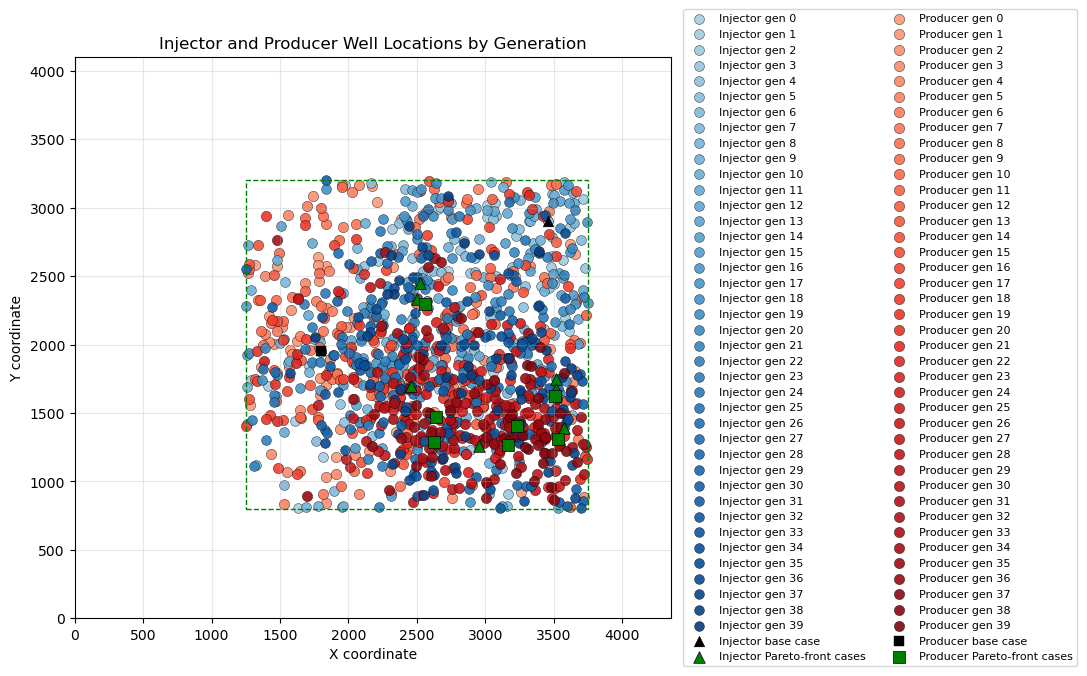

In [6]:
def plot_combined_well_locations(df_cv, cols):
    gen_col = cols["generation"]

    unique_gens = sorted(df_cv[gen_col].dropna().unique())
    blue_shades = generation_shades(len(unique_gens), cmap_name="Blues")
    red_shades = generation_shades(len(unique_gens), cmap_name="Reds")

    gen_to_blue = {g: blue_shades[i] for i, g in enumerate(unique_gens)}
    gen_to_red = {g: red_shades[i] for i, g in enumerate(unique_gens)}

    fig, ax = plt.subplots(figsize=(11, 8))

    for gen in unique_gens:
        df_gen = df_cv[df_cv[gen_col] == gen]

        ax.scatter(
            df_gen[cols["inj_x"]],
            df_gen[cols["inj_y"]],
            color=gen_to_blue[gen],
            marker="o",
            s=50,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9,
            label=f"Injector gen {gen}"
        )

        ax.scatter(
            df_gen[cols["prod_x"]],
            df_gen[cols["prod_y"]],
            color=gen_to_red[gen],
            marker="o",
            s=55,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9,
            label=f"Producer gen {gen}"
        )

    # draw optimizer search bounds rectangle if all limits are provided
    rect = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=1,
            label="Search bounds"
        )
    ax.add_patch(rect)

    # Base case and optimized case points
    add_casepoints_inj(ax)
    add_casepoints_prod(ax)

    ax.set_xlim(0, 4360)
    ax.set_ylim(0, 4100)
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_title("Injector and Producer Well Locations by Generation")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

    # reorder legend entries to group injectors and producers together
    handles, labels = ax.get_legend_handles_labels()
    # Separate injector and producer entries
    inj = [(h, l) for h, l in zip(handles, labels) if "Injector" in l]
    prod = [(h, l) for h, l in zip(handles, labels) if "Producer" in l]
    ordered = inj + prod
    handles_ordered, labels_ordered = zip(*ordered)
    ax.legend(handles_ordered, labels_ordered, loc="center left", fontsize=8, ncol=2, bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

plot_combined_well_locations(df_controlvector, cols)

### INJ scatter plot with HEAT contour

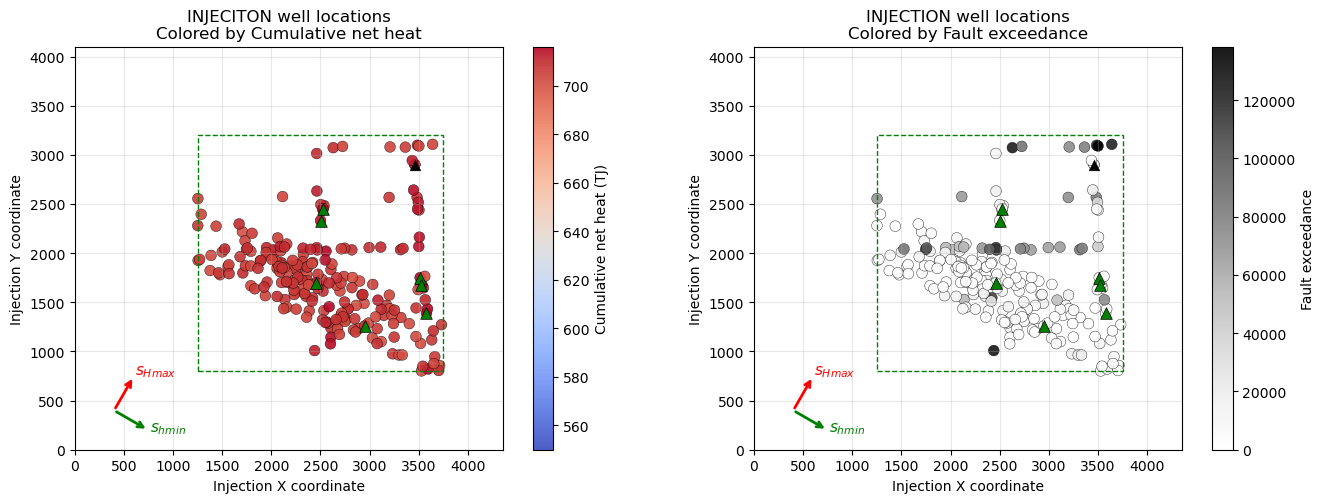

In [13]:
def plot_injector_by_objective(df_cv, cols):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    # Plot 1 for HEAT objective
    norm1 = colors.Normalize(
        vmin=df_cv[cols["objective1"]].min(),
        vmax=df_cv[cols["objective1"]].max()
    )

    # Option to plot trimmed data with values above 22.00 MWy only
    trim_heat = True

    if trim_heat:
        df_trimmed_heat = df_cv[df_cv[cols["objective1"]] > 700.00]
        sc1 = axes[0].scatter(
        df_trimmed_heat[cols["inj_x"]],
        df_trimmed_heat[cols["inj_y"]],
        c=df_trimmed_heat[cols["objective1"]],
        cmap="coolwarm",
        norm=norm1,
        s=60,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.9
    )
    else:
        sc1 = axes[0].scatter(
        df_cv[cols["inj_x"]],
        df_cv[cols["inj_y"]],
        c=df_cv[cols["objective1"]],
        cmap="coolwarm",
        norm=norm1,
        s=60,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.9
    )



    # draw optimizer search bounds rectangle if all limits are provided
    rect1 = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=1,
            label="Search bounds"
        )    
    axes[0].add_patch(rect1)

    # Base case and optimized case points
    add_casepoints_inj(axes[0])

    add_stress_arrows(axes[0], length=400)

    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label("Cumulative net heat (TJ)")
    axes[0].set_xlim(0, 4360)
    axes[0].set_ylim(0, 4100)
    axes[0].set_xlabel("Injection X coordinate")
    axes[0].set_ylabel("Injection Y coordinate")
    axes[0].set_title("INJECITON well locations\nColored by Cumulative net heat")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect("equal", adjustable="box")

    # Plot 2 for FaultExceedance objective
    
    norm2 = colors.Normalize(
        vmin=df_cv[cols["objective2"]].min(),
        vmax=df_cv[cols["objective2"]].max()
    )

    # Option to plot trimmed data with non-zero exceedance values only
    trim_react = False
    trim_react_heat = True

    if trim_react:
        df_trimmed_fault = df_cv[df_cv[cols["objective2"]] > 0]
        sc2 = axes[1].scatter(
            df_trimmed_fault[cols["inj_x"]],
            df_trimmed_fault[cols["inj_y"]],
            c=df_trimmed_fault[cols["objective2"]],
            cmap="Greys",
            norm=norm2,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9
        )
    elif trim_react_heat:
        df_trimmed_heat = df_cv[df_cv[cols["objective1"]] > 700.00]
        sc2 = axes[1].scatter(
            df_trimmed_heat[cols["inj_x"]],
            df_trimmed_heat[cols["inj_y"]],
            c=df_trimmed_heat[cols["objective2"]],
            cmap="Greys",
            norm=norm2,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9
        )
    else:
        sc2 = axes[1].scatter(
            df_cv[cols["inj_x"]],
            df_cv[cols["inj_y"]],
            c=df_cv[cols["objective2"]],
            cmap="Greys",
            norm=norm2,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9
        )

    # draw optimizer search bounds rectangle if all limits are provided
    rect2 = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=1,
            label="Search bounds"
        )    
    axes[1].add_patch(rect2)

    # Base case and optimized case points
    add_casepoints_inj(axes[1])

    add_stress_arrows(axes[1], length=400)

    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("Fault exceedance")
    axes[1].set_xlim(0, 4360)
    axes[1].set_ylim(0, 4100)
    axes[1].set_xlabel("Injection X coordinate")
    axes[1].set_ylabel("Injection Y coordinate")
    axes[1].set_title("INJECTION well locations\nColored by Fault exceedance")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect("equal", adjustable="box")


    plt.tight_layout()
    plt.show()

plot_injector_by_objective(df_controlvector, cols)

### PROD scatter plot with HEAT contour

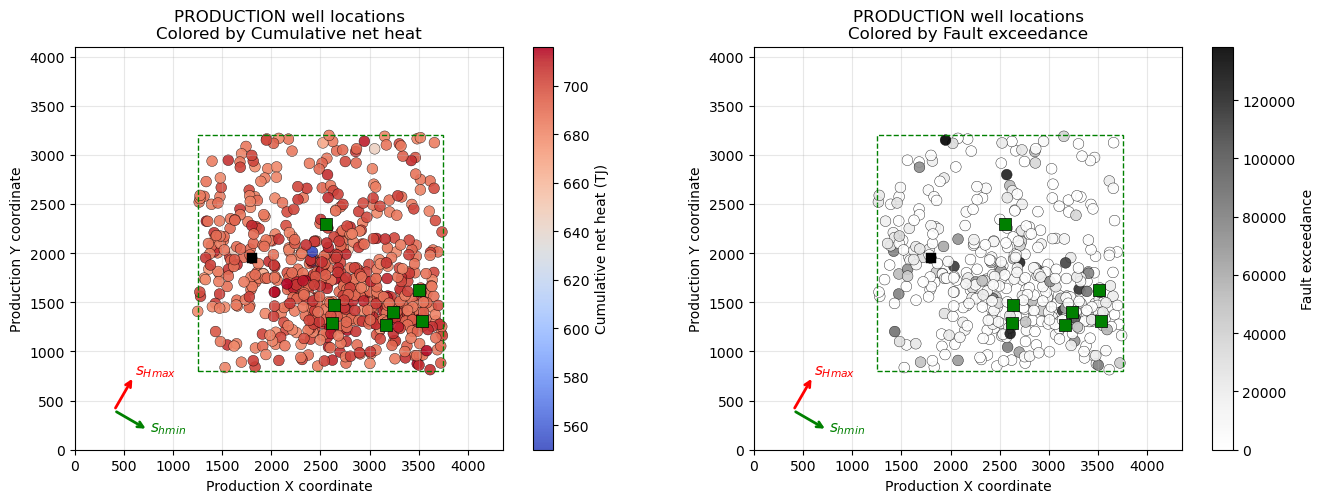

In [8]:
def plot_injector_by_objective(df_cv, cols):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))


    # Plot 1 for HEAT objective
    norm1 = colors.Normalize(
        vmin=df_cv[cols["objective1"]].min(),
        vmax=df_cv[cols["objective1"]].max()
    )

    # Option to plot trimmed data with values above 22.00 MWy only
    trim_heat = False

    if trim_heat:
        df_trimmed_heat = df_cv[df_cv[cols["objective1"]] > 700.00]
        sc1 = axes[0].scatter(
            df_trimmed_heat[cols["prod_x"]],
            df_trimmed_heat[cols["prod_y"]],
            c=df_trimmed_heat[cols["objective1"]],
            cmap="coolwarm",
            norm=norm1,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9 )
    else:        
        sc1 = axes[0].scatter(
            df_cv[cols["prod_x"]],
            df_cv[cols["prod_y"]],
            c=df_cv[cols["objective1"]],
            cmap="coolwarm",
            norm=norm1,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9)

    # draw optimizer search bounds rectangle if all limits are provided
    rect1 = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=1,
            label="Search bounds"
        )    
    axes[0].add_patch(rect1)

    # Base case and optimized case points
    add_casepoints_prod(axes[0])

    add_stress_arrows(axes[0], length=400)

    cbar1 = plt.colorbar(sc1, ax=axes[0])
    cbar1.set_label("Cumulative net heat (TJ)")
    axes[0].set_xlim(0, 4360)
    axes[0].set_ylim(0, 4100)
    axes[0].set_xlabel("Production X coordinate")
    axes[0].set_ylabel("Production Y coordinate")
    axes[0].set_title("PRODUCTION well locations\nColored by Cumulative net heat")
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect("equal", adjustable="box")

    # Plot 2 for FaultExceedance objective
    
    norm2 = colors.Normalize(
        vmin=df_cv[cols["objective2"]].min(),
        vmax=df_cv[cols["objective2"]].max()
    )

    # Option to plot trimmed data with non-zero exceedance values only
    trim = True

    if trim:
        df_trimmed = df_cv[df_cv[cols["objective2"]] > 0]
        sc2 = axes[1].scatter(
            df_trimmed[cols["prod_x"]],
            df_trimmed[cols["prod_y"]],
            c=df_trimmed[cols["objective2"]],
            cmap="Greys",
            norm=norm2,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9
        )
    else:
        sc2 = axes[1].scatter(
            df_cv[cols["prod_x"]],
            df_cv[cols["prod_y"]],
            c=df_cv[cols["objective2"]],
            cmap="Greys",
            norm=norm2,
            s=60,
            edgecolor="black",
            linewidth=0.3,
            alpha=0.9
        )

    # draw optimizer search bounds rectangle if all limits are provided
    rect2 = Rectangle(
        (search_xmin, search_ymin),
         search_xmax - search_xmin,
         search_ymax - search_ymin,
            fill=False,
            edgecolor="green",
            linestyle="--",
            linewidth=1,
            label="Search bounds"
        )    
    axes[1].add_patch(rect2)

    # Base case and optimized case points
    add_casepoints_prod(axes[1])

    add_stress_arrows(axes[1], length=400)

    cbar2 = plt.colorbar(sc2, ax=axes[1])
    cbar2.set_label("Fault exceedance")
    axes[1].set_xlim(0, 4360)
    axes[1].set_ylim(0, 4100)
    axes[1].set_xlabel("Production X coordinate")
    axes[1].set_ylabel("Production Y coordinate")
    axes[1].set_title("PRODUCTION well locations\nColored by Fault exceedance")
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect("equal", adjustable="box")


    plt.tight_layout()
    plt.show()

plot_injector_by_objective(df_controlvector, cols)

## OBJECTIVE FUNCTION PROGRESSION

### HELPERS for plotting

In [9]:
def plot_pareto_solution_progression(df_pareto):
    """
    Plot how each Pareto-front solution changes over generations for both objectives.
    One line is drawn for each pareto_rank.
    """
    required_cols = ["generation", "pareto_rank", "Heat", "FaultExceedance"]
    for col in required_cols:
        if col not in df_pareto.columns:
            raise KeyError(f"Required column missing: {col}")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    n_pareto = len(df_pareto["pareto_rank"].unique())

    # Heat colors: red -> yellow -> green
    heat_colors = plt.cm.rainbow(np.linspace(0, 1, n_pareto))

    # Fault colors: blue -> yellow
    fault_colors = plt.cm.rainbow(np.linspace(0, 1, n_pareto))

    for pareto_rank, df_rank in df_pareto.groupby("pareto_rank"):
        df_rank = df_rank.sort_values("generation")
        label = f"Pareto rank {int(pareto_rank)}"

        axes[0].plot(
            df_rank["generation"],
            df_rank["Heat"],
            marker='x',
            color=heat_colors[int(pareto_rank)],
            linewidth=1.5,
            label=label,
        )
        axes[1].plot(
            df_rank["generation"],
            df_rank["FaultExceedance"],
            marker='x',
            color=fault_colors[int(pareto_rank)],
            linewidth=1.5,
            label=label,
        )

    axes[0].set_title("Pareto heat progression")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Cumulative net heat (TJ)")
    axes[0].grid(True, alpha=0.3)
    axes[0].tick_params(labelbottom=True)

    axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

    axes[1].set_title("Pareto fault-exceedance progression")
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Fault exceedance")
    axes[1].grid(True, alpha=0.3)

    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plt.show()


def plot_population_objective_progression(df_population_plot):
    """
    Plot all individual solutions by population order, respecting generation order.
    Top subplot: Heat crosses plus min/max/avg lines.
    Bottom subplot: FaultExceedance crosses plus min/max/avg lines.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    x = df_population_plot["population_global_index"]

    axes[0].plot(
        x,
        df_population_plot["ind_heat"]*conv,
        linestyle="None",
        marker="x",
        color="0.65",
        markersize=5,
        alpha=0.7,
        label="Individual solutions",
    )
    axes[0].plot(x, df_population_plot["min_Heat"], color='0.8', linestyle="-", linewidth=1.6, label="Minimum")
    axes[0].plot(x, df_population_plot["max_Heat"], color='black', linestyle="-", linewidth=1.6, label="Maximum")
    axes[0].plot(x, df_population_plot["avg_Heat"], color='0.5', linestyle="-", linewidth=1.8, label="Average")
    axes[0].set_ylabel("Cumulative net heat (TJ)")
    axes[0].set_title("Heat objective across population order")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

    axes[1].plot(
        x,
        df_population_plot["ind_fault_exceedance"],
        linestyle="None",
        marker="x",
        color="0.65",
        markersize=5,
        alpha=0.7,
        label="Individual solutions",
    )
    axes[1].plot(x, df_population_plot["min_FaultExceedance"], color='0.8', linestyle="-", linewidth=1.6, label="Minimum")
    axes[1].plot(x, df_population_plot["max_FaultExceedance"], color='black', linestyle="-", linewidth=1.6, label="Maximum")
    axes[1].plot(x, df_population_plot["avg_FaultExceedance"], color='0.5', linestyle="-", linewidth=1.8, label="Average")
    axes[1].set_xlabel("Population order by generation")
    axes[1].set_ylabel("Fault exceedance")
    axes[1].set_title("Fault-exceedance objective across population order")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

    # # Draw generation boundaries once per generation for readability.
    # generation_starts = df_population_plot.groupby("generation")["population_global_index"].min().values
    # for ax in axes:
    #     for xpos in generation_starts[1:]:
    #         ax.axvline(x=xpos - 0.5, color="0.85", linewidth=0.8, zorder=0)

    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plt.show()


### Pareto-front objective progression plot

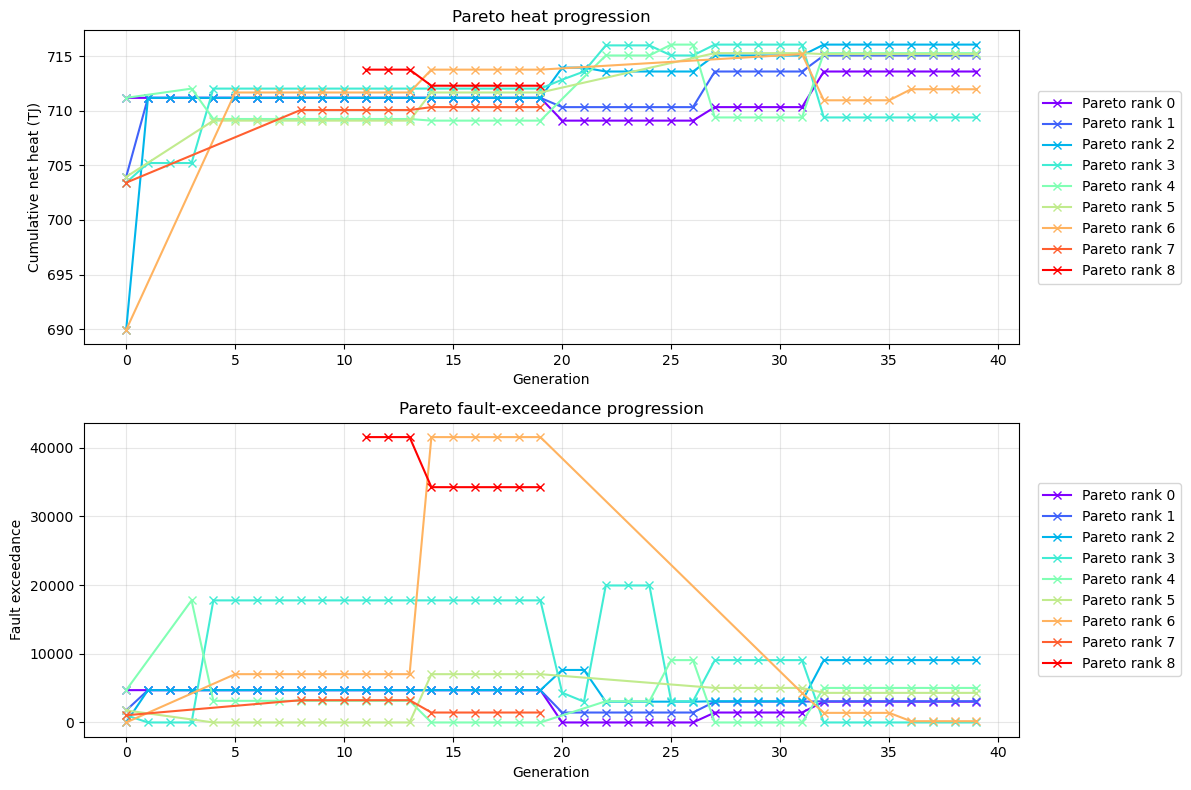

In [10]:
plot_pareto_solution_progression(df_pareto_progression)

### Population-wise objective progression plot

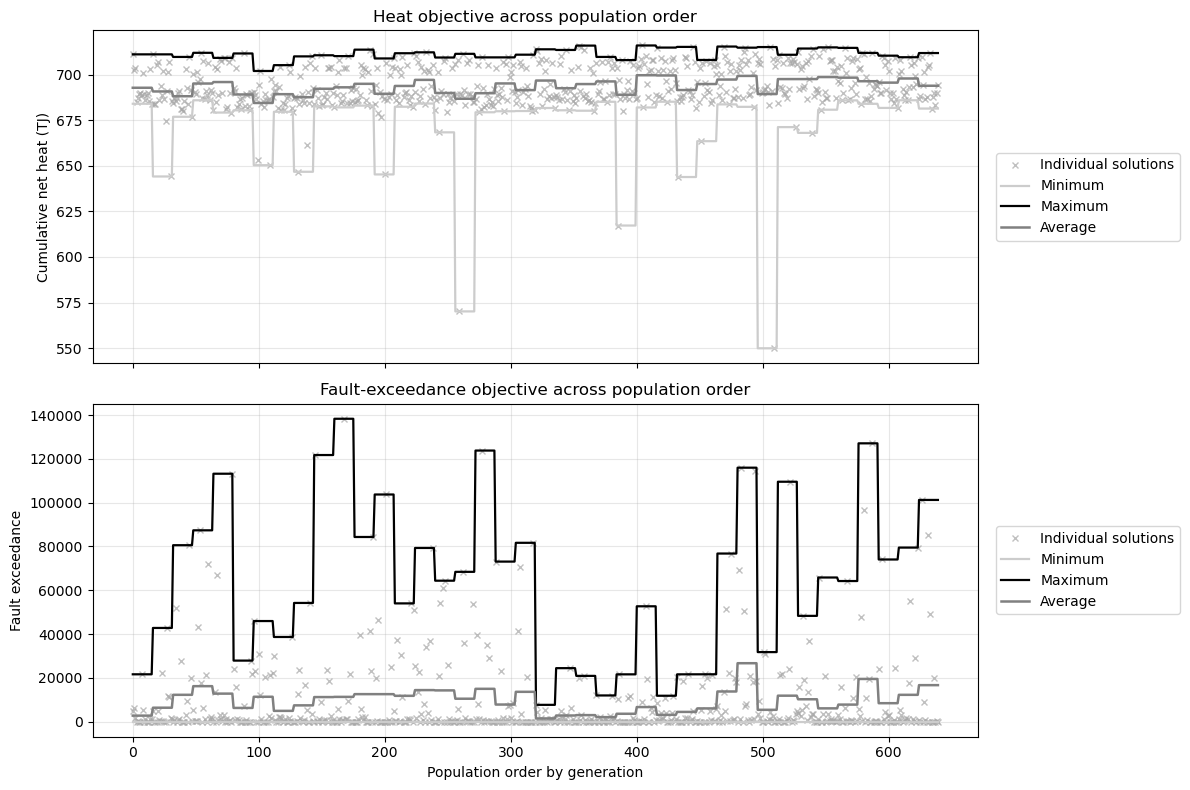

In [11]:
plot_population_objective_progression(df_population_progression)